# Text Clustering

* * *

In the previous tutorial, we turned text into vectors. In this tutorial, we will use those vectors to discover structure in the corpus by clustering documents (grouping documents that are similar to one another).

The problem is there's no single "right answer" to clustering. We can cluster the same documents in many different ways, and there is no objective way to say which one is best. This is reason why clustering is often called an *"unsupervised"* method. 

This tutorial walks through four unsupervised methods on the same dataset:

- KMeans — partitions documents into k groups based on distance from cluster centroids
- HDBSCAN — finds dense regions in the data, selects the number of clusters automatically, and flags outliers
- LDA — represents each document as a mixture of probabilistic topics based on word counts
- BERTopic — uses a modern pipeline combining embeddings, dimensionality reduction, density-based clustering, and TF-IDF topic representation

We will use each method to 
1) assign documents to clusters or topics, 
2) measure how strongly each document belongs to its assigned group,
3) examine how large or balanced those groups are. 
4) interpret what each cluster/topic represents by comparing it with the known category labels
5) inspect representative documents and top words
6) visualize the results with UMAP. 

The goal is not simply to find the “best” method. Instead, we want to understand what each method reveals about the same corpus, what it hides, and what kinds of assumptions it makes.
  
Adapted from:
- https://github.com/dlab-berkeley/Computational-Social-Science-Training-Program

In [ ]:
# download libraries
#!pip install scattertext
#!pip install wordcloud
#!pip install umap-learn
#!pip install hdbscan
#!pip install bertopic
#!pip install sentence-transformers

In [6]:
import pandas as pd
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt


# Load data (for public sharing)

We'll use the Consumer Financial Protection Bureau's [Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/). 


The full database has millions of records across dozens of product categories. The code below downloads a stratified sample of 4,000 complaints — 1,000 each from four product categories: `Mortgage`, `Credit card or prepaid card`, `Debt collection`, and `Student loan`. These four categories are interesting because they cover distinct financial domains yet share overlapping vocabulary (payments, accounts, fees), making them a good test bed for clustering and topic modeling.

In [7]:
# Code used for initial data cleaning and sampling
# cfpb = pd.read_csv('cfpb_raw1.csv')

# target_products = [
#     'Mortgage',
#     'Credit card or prepaid card',
#     'Debt collection',
#     'Student loan',
# ]
# cfpb = cfpb[cfpb['Product'].isin(target_products)]

# cfpb = cfpb.dropna(subset = ['Consumer complaint narrative'])

# # cfpb_sample = cfpb.sample(frac=0.01, random_state=42)
# cfpb_sample = (cfpb.groupby('Product', group_keys=True) 
#                    .apply(lambda g: g.sample(n=min(len(g), 1000), random_state=42))
#                    .reset_index(level='Product') 
#                    .reset_index(drop=True))     

# print(cfpb_sample['Product'].value_counts().loc[target_products])
# cfpb_sample.to_csv('cfpb_sample.csv', index=False)


In [ ]:
# Load data (for public sharing) 
import os
import gdown

# Upload the data file to your Google Drive, and turn on the link sharing
# Replace 'YOUR_FILE_ID' with the actual file ID from your public Google Drive link e.g., "https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing"
file_id = '1VwrbAod_L2rdxw_LnWhS4ogQh_BChmum'

# Name for the downloaded file in Colab
output_filename = 'cfpb_sample.csv'

if file_id and not os.path.exists(output_filename):
    gdown.download(id=file_id, output=output_filename, quiet=False)
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Using existing file '{output_filename}'.")

# Now you can load it with pandas
cfpb= pd.read_csv(output_filename)
display(cfpb.head())


Using existing file 'cfpb_sample.csv'.


,Product,Date received,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,Credit card or prepaid card,2022-12-08,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Problem with personal statement of dispute,I was on vacation from XX/XX/2022 to XX/XX/XXX...,Company has responded to the consumer and the ...,BARCLAYS BANK DELAWARE,CA,92596,NaN,Consent provided,Web,2022-12-08,Closed with explanation,Yes,NaN,6298164
1,Credit card or prepaid card,2021-08-12,Gift card,Unexpected or other fees,NaN,Hello - my unused Visa had a value of XXXX dol...,Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",CA,92024,NaN,Consent provided,Web,2021-08-12,Closed with explanation,Yes,NaN,4626212
2,Credit card or prepaid card,2020-02-13,General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card,I signed up for XXXX XXXX AAdvantage MasterCa...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",MO,641XX,NaN,Consent provided,Web,2020-02-13,Closed with explanation,Yes,NaN,3530891
3,Credit card or prepaid card,2023-06-12,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"I ordered some shoes from a small store, and i...",NaN,DISCOVER BANK,CA,91307,NaN,Consent provided,Web,2023-06-12,Closed with non-monetary relief,Yes,NaN,7106047
4,Credit card or prepaid card,2022-06-28,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,This is for commenity bank. I have a 0 % inter...,NaN,"Bread Financial Holdings, Inc.",CA,95842,NaN,Consent provided,Web,2022-06-28,Closed with monetary relief,Yes,NaN,5717034


In [9]:
# Cleaning and tokenization
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from string import punctuation

def text_cleaning(text):
    stop_words = STOP_WORDS
    punc = set(punctuation) - {'.', '?', '!'}

    # 1) Lowercase
    text = text.lower()
    # 2) Remove redacted text (XX, XXXX)
    text = re.sub(r'\b[Xx]{2,}\b', '', text)
    # 3) Replace digit sequences with placeholder
    text = re.sub(r'\d+', 'DIGIT', text)
    # 4) Replace punctuation with spaces (so attached words split apart)
    text = "".join(ch if ch not in punc else ' ' for ch in text)
    # 5) Remove stop words (also removes extra spaces around them)
    text = ' '.join(w for w in text.split() if w not in stop_words)
    # 6) Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply and save to a new column
cfpb['text_clean'] = cfpb['Consumer complaint narrative'].map(text_cleaning)
cfpb['text_clean'].head()

# Tokenize the cleaned text
nlp = spacy.load('en_core_web_sm', 
                 disable=['ner'])
cfpb['doc'] = list(nlp.pipe(cfpb['text_clean'], batch_size=100, n_process=6))
cfpb['tokens'] = cfpb['doc'].apply(lambda doc: [token.text for token in doc])
cfpb['lemmas'] = cfpb['doc'].apply(lambda doc: [token.lemma_ for token in doc])

# Describe the data

## Descriptive Stats

In [10]:
# count number of characters
cfpb['complaint_len'] = cfpb['text_clean'].apply(len)

# count number of words
cfpb['word_count'] = cfpb['text_clean'].apply(lambda x: len(str(x).split()))

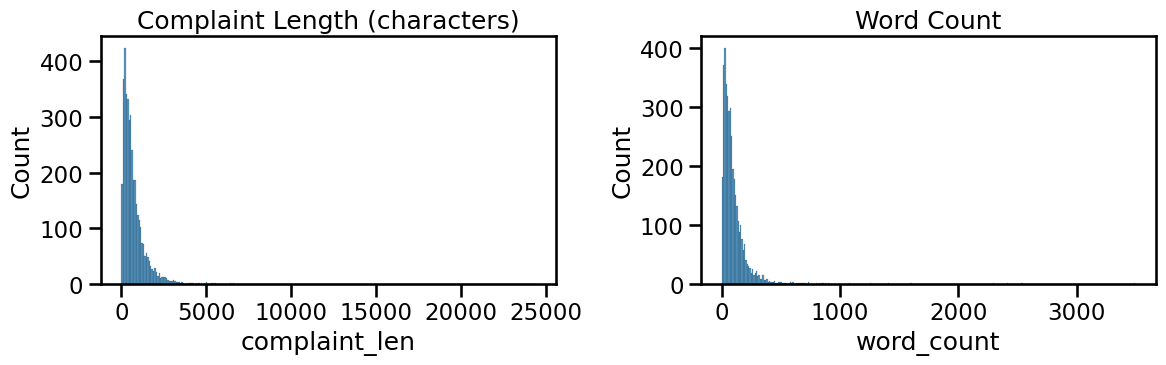

In [11]:
sns.set_context("talk")  # 옵션: "paper", "notebook"(기본), "talk", "poster"

# visualize the distributions of the count features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cfpb, x="complaint_len", ax=axes[0])
axes[0].set_title("Complaint Length (characters)")

sns.histplot(cfpb, x="word_count", ax=axes[1])
axes[1].set_title("Word Count")

plt.tight_layout()
plt.show()

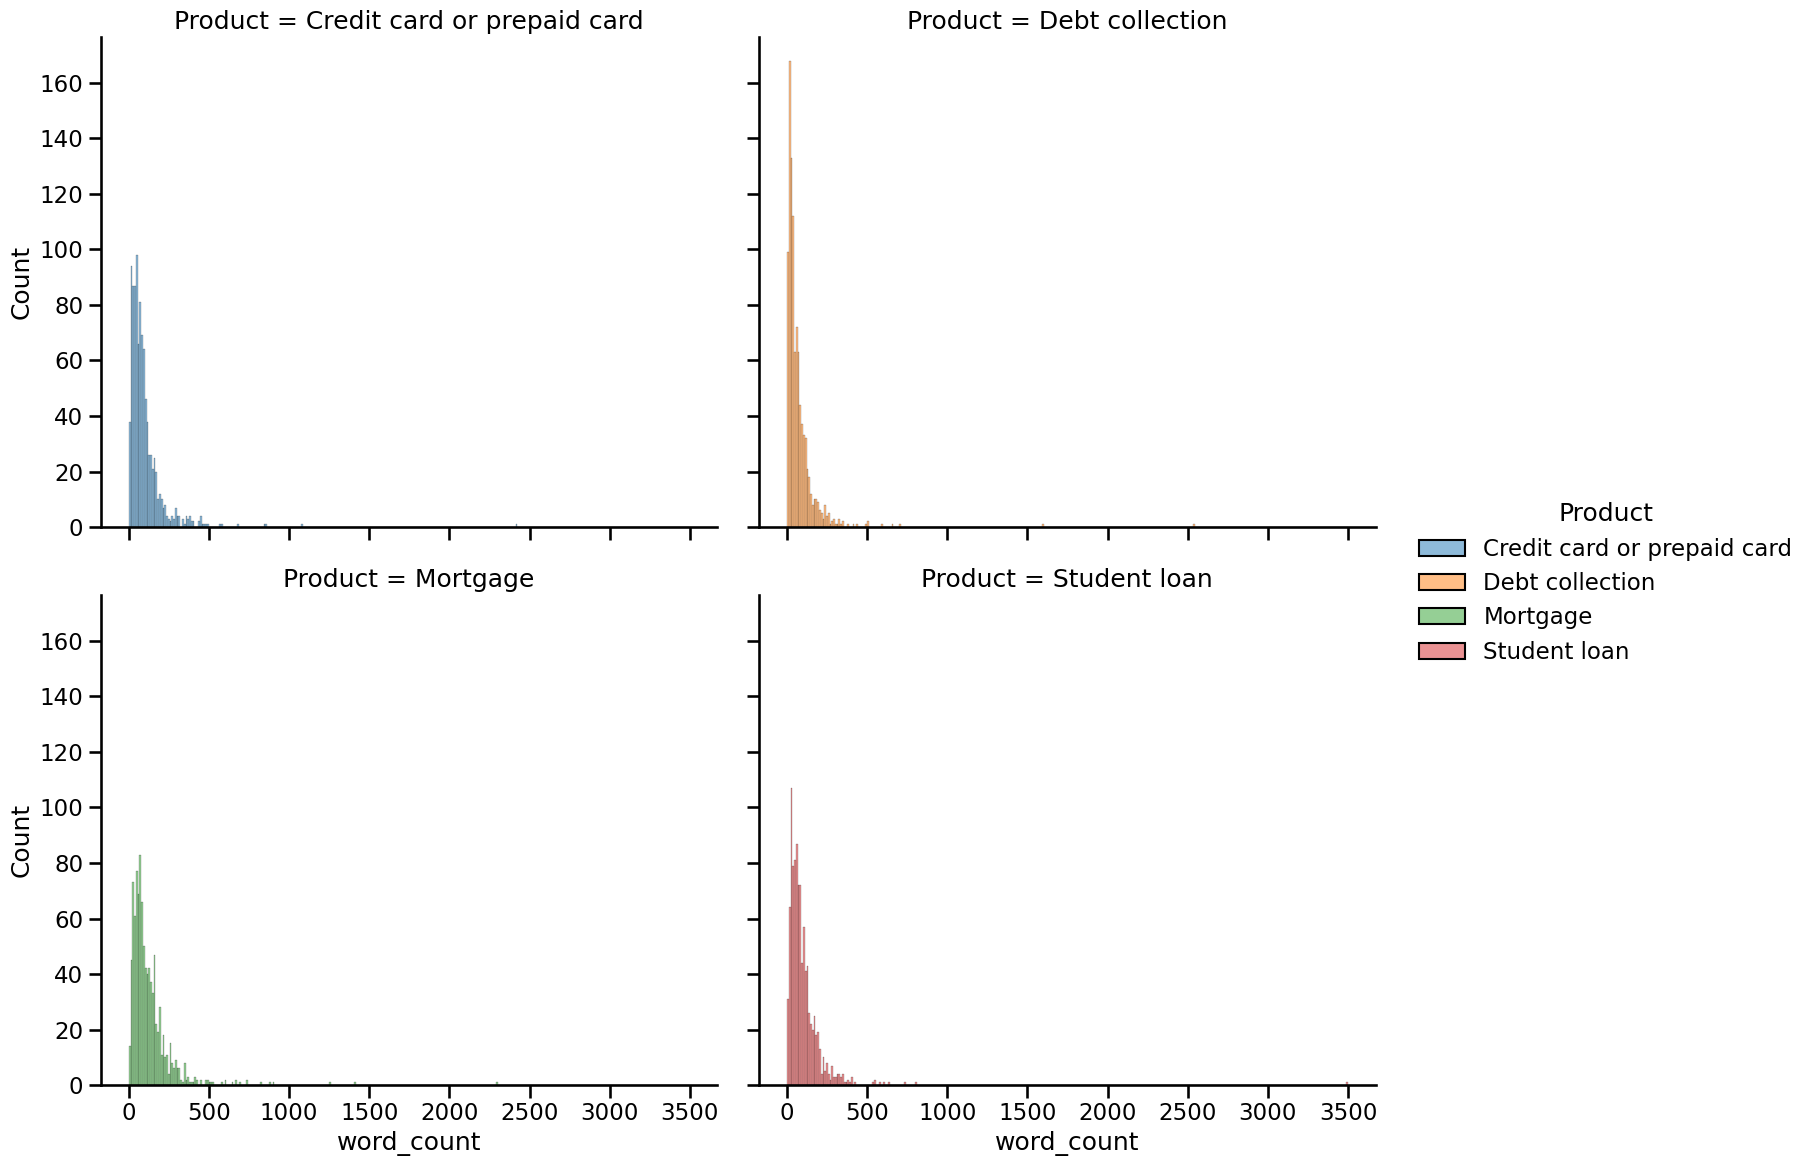

In [12]:
# histogram of word count by loan product 
sns.displot(
    cfpb,
    x='word_count',
    hue='Product',
    col='Product',
    col_wrap=2,      # number of plots per row → 2 rows × 3 cols for 5 categories
    height=6,        # height of each subplot
    aspect=1.2,      # width / height ratio
)
plt.show()


## Word Cloud

A [wordcloud](https://github.com/amueller/word_cloud) is a quick visual summary of which words appear most often in a corpus — larger words are more frequent. It's useful as a first-pass exploratory tool to get a feel for dominant vocabulary. Below, we join all preprocessed tokens into a single string and pass it to `WordCloud.generate()`, which counts word frequencies internally and lays out the visualization.

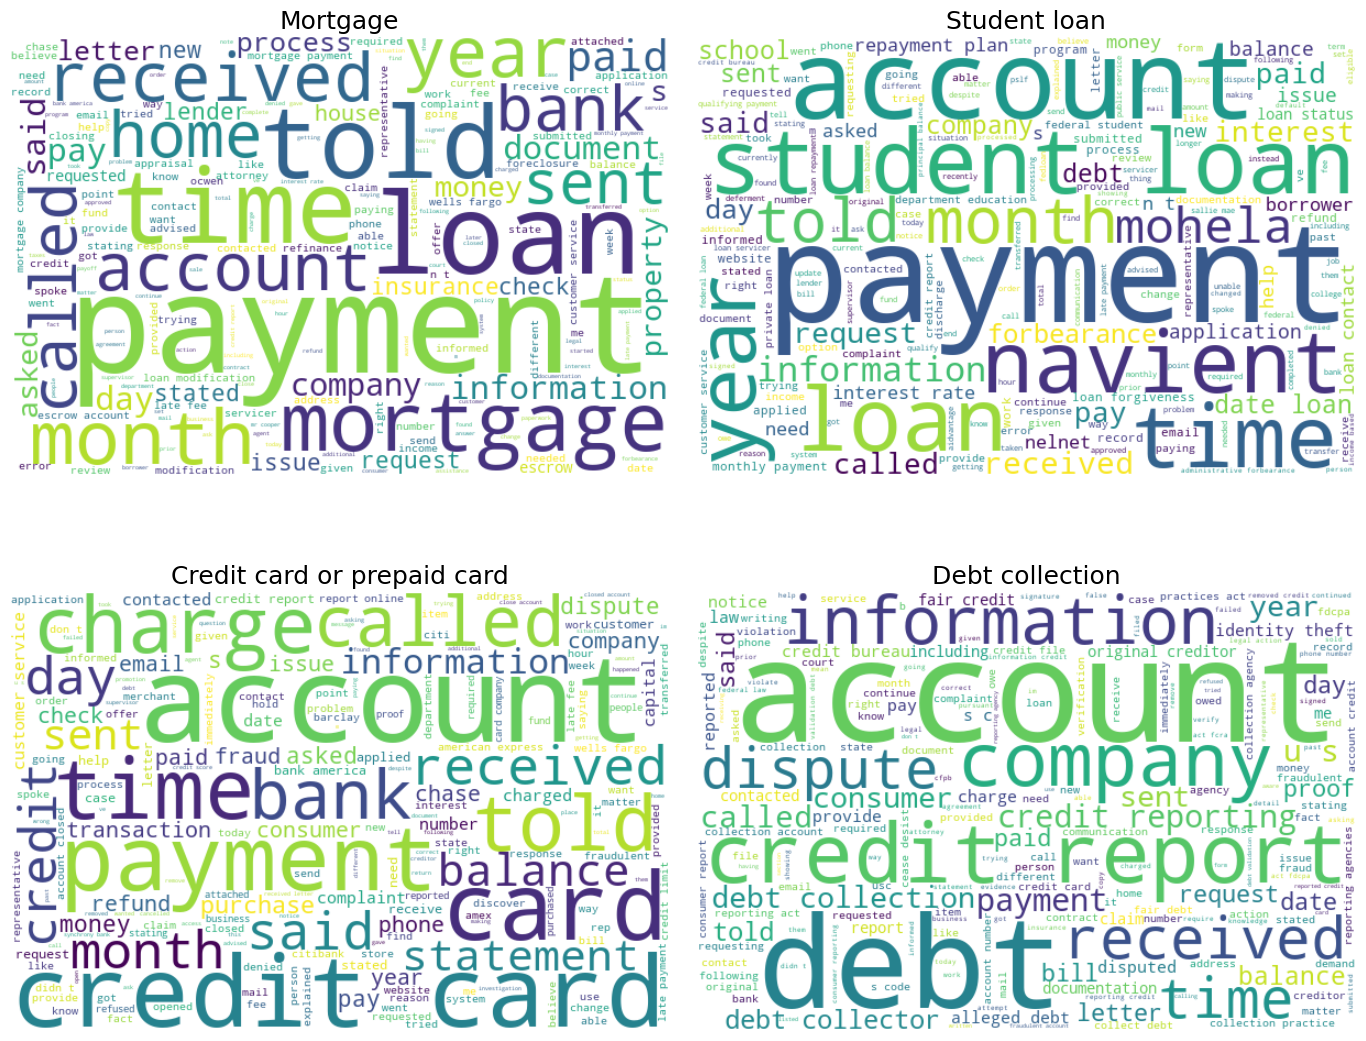

In [13]:
from wordcloud import WordCloud

# Build text for each product
mortgage_text = ' '.join(cfpb.loc[cfpb['Product'] == 'Mortgage', 'text_clean'])
student_text  = ' '.join(cfpb.loc[cfpb['Product'] == 'Student loan', 'text_clean'])
credit_text  = ' '.join(cfpb.loc[cfpb['Product'] == 'Credit card or prepaid card', 'text_clean'])
debt_text    = ' '.join(cfpb.loc[cfpb['Product'] == 'Debt collection', 'text_clean'])

# Generate word clouds
wc_kwargs = dict(
    random_state=40,
    background_color='white',
    width=600,
    height=400,
    stopwords=['DIGIT'],
    # collocations=False,
)
wc_mortgage = WordCloud(**wc_kwargs).generate(mortgage_text)
wc_student  = WordCloud(**wc_kwargs).generate(student_text)
wc_credit   = WordCloud(**wc_kwargs).generate(credit_text)
wc_debt     = WordCloud(**wc_kwargs).generate(debt_text)

# Plot side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(wc_mortgage, interpolation='bilinear')
axes[0, 0].set_title('Mortgage', fontsize=18)
axes[0, 0].axis('off')

axes[0, 1].imshow(wc_student, interpolation='bilinear')
axes[0, 1].set_title('Student loan', fontsize=18)
axes[0, 1].axis('off')

axes[1, 0].imshow(wc_credit, interpolation='bilinear')
axes[1, 0].set_title('Credit card or prepaid card', fontsize=18)
axes[1, 0].axis('off')

axes[1, 1].imshow(wc_debt, interpolation='bilinear')
axes[1, 1].set_title('Debt collection', fontsize=18)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



## ScatterText

[ScatterText](https://spacy.io/universe/project/scattertext) visualize how language differs among document types

In [14]:
import scattertext as st
import spacy

two_cat_df = cfpb[cfpb['Product'].isin(['Credit card or prepaid card', 'Debt collection'])]

# load reduced nlp + parsing first + batch process
corpus = st.CorpusFromParsedDocuments(
    two_cat_df,
    category_col='Product',
    parsed_col='doc',
).build()


# load default nlp + no parsing + single process 
# nlp = spacy.load('en_core_web_sm')

# corpus = st.CorpusFromPandas(
#     two_cat_df,
#     category_col='Product',
#     text_col='text_clean',  
#     nlp=nlp
# ).build()

In [15]:
html = st.produce_scattertext_explorer(corpus,
                                       category='Credit card or prepaid card',
                                       category_name='Credit card or prepaid card',
                                       not_category_name='Debt collection',
                                       width_in_pixels=1000,
                                       minimum_term_frequency=10,
                                       max_terms=2000,
                                    #    metadata=cfpb['Complaint ID']
                                    )
open("CFPB Sentiment.html", 'wb').write(html.encode('utf-8'))

2300386

# Unsupervised Methods for NLP

In the previous tutorial, we built numeric representations of text — from sparse bag-of-words to dense Word2Vec and contextual BERT embeddings. We also saw how to project those vectors into 2D for visualization:

- PCA   → linear, easy to interpret, captures global variance directions
- t-SNE → non-linear, great for revealing local clusters
- UMAP  → modern standard, fast, preserves both local and global structure

<img src='./images/fashion_mnist.png' alt="fashion" width="800">

(image from [here](https://www.kaggle.com/discussions/getting-started/120349))


These tools help us *see* the shape of the semantic space, but they don't tell us *where the groups are*. To actually identify groupings of documents, we turn to unsupervised algorithms. Below are two main approaches:

**1. Clustering — "which documents belong together?"**

Clustering algorithms partition documents into groups based on similarity in vector space. Each document ends up in (typically) one cluster.

- *K-means* — the classic baseline. Fast and intuitive, but you must choose `k` ahead of time.
- *Hierarchical clustering* — builds a tree of nested groupings (dendrogram). 
- *HDBSCAN* — a modern density-based method. No need to set `k`. 

**Note:** clustering can also be applied to *word* vectors (grouping semantically related words). We'll see word-level groupings re-emerge in the topic modeling section, where each topic is itself a cluster of related words.


**2. Topic Modeling — "what themes run through this corpus?**

Topic models go a step further: instead of assigning each document to a single cluster, they treat documents as *mixtures of latent topics*, and each topic as a distribution over words.

- *LDA (Latent Dirichlet Allocation)* — the classic probabilistic topic model. Still widely cited in social-science papers; produces interpretable word lists per topic, but assumes bag-of-words input and can struggle with short texts.
- *BERTopic* — a modern alternative that runs sentence embeddings → UMAP → HDBSCAN → class-based TF-IDF. Captures semantic context that LDA misses, handles short documents well, and often produces cleaner topics out of the box.



Let's start by creating our tf-idf matrix again. 

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a tfidf vectorizer
vectorizer = TfidfVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

# Fit and transform on the complaint narratives
tf_dtm = vectorizer.fit_transform(cfpb['text_clean'])

# Create a tf-idf dataframe
tfidf = pd.DataFrame(tf_dtm.todense(),
                     columns=vectorizer.get_feature_names_out(),
                     index=cfpb.index)
tfidf.head()


,aa,aadvantage,aafes,ab,aback,abandoned,abide,abiding,abilities,ability,...,younger,youre,youve,yr,yrs,zero,zeroed,zip,zone,zoom
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.127697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


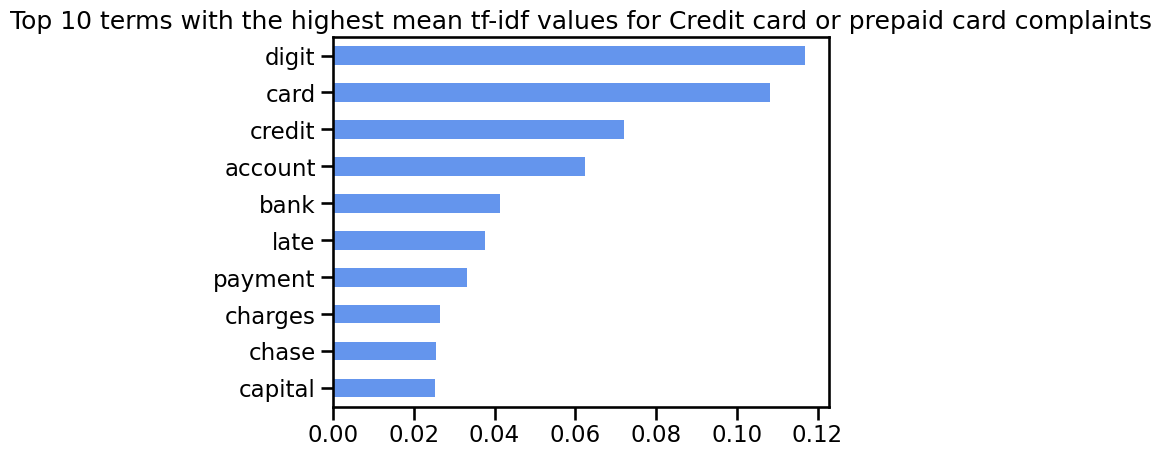

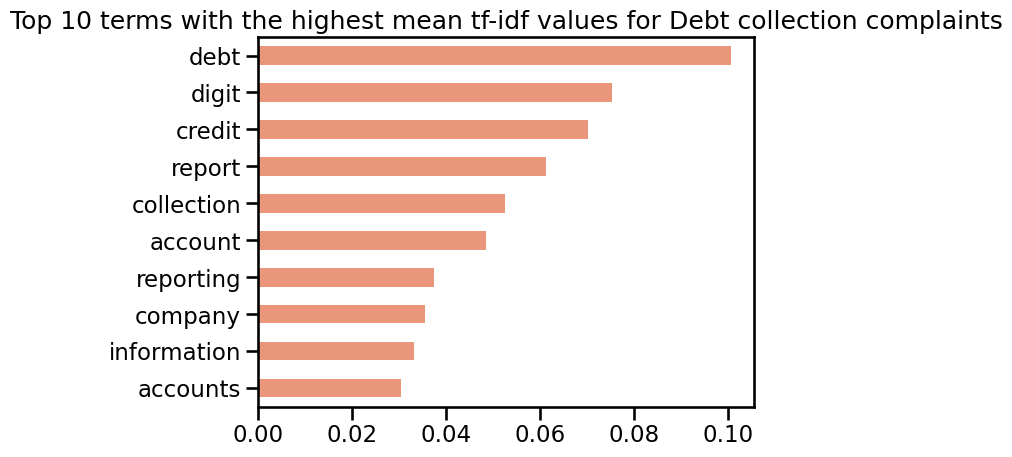

In [17]:
# Boolean masks for the two product categories
mortgage_index = cfpb[cfpb['Product'] == 'Credit card or prepaid card'].index
debt_index  = cfpb[cfpb['Product'] == 'Debt collection'].index

# Mean tf-idf per token within each group
mortgage = tfidf.loc[mortgage_index].mean().sort_values(ascending=False).head(10)
debt  = tfidf.loc[debt_index].mean().sort_values(ascending=False).head(10)

# Plot top 10 terms with the highest mean tf-idf values for each product type
mortgage.plot(kind='barh',
              color='cornflowerblue',
              title='Top 10 terms with the highest mean tf-idf values for Credit card or prepaid card complaints')
plt.gca().invert_yaxis()  # highest at the top
plt.show()

debt.plot(kind='barh',
          color='darksalmon',
          title='Top 10 terms with the highest mean tf-idf values for Debt collection complaints')
plt.gca().invert_yaxis()
plt.show()


## Clustering
### K-Means
KMeans partitions documents into `k` groups by finding `k` "centers" (centroids) and assigning each document to its nearest one. It's the most widely used clustering algorithm but you must choose `k` ahead of time, and it assumes roughly spherical clusters.

The algorithm iterates:
1. Pick `k` initial centroids (e.g., random or k-means++)
2. Assign each document to the nearest centroid → forms clusters
3. Move each centroid to the mean position of its assigned documents
4. Repeat until centroids stop moving (convergence)

<img src='./images/Kmeans-implementation.png' alt="kmeans" width="800">

(image from [here](https://www.geeksforgeeks.org/machine-learning/k-means-vs-k-means-clustering-algorithm/))

In [18]:
from sklearn.cluster import KMeans

# Fit KMeans on the TF-IDF matrix
kmeans = KMeans(
    n_clusters=4,        # number of clusters
    max_iter=300,        # max iterations
    n_init=10,           # number of random initializations
    random_state=42      # reproducibility
).fit(tf_dtm)            # use the sparse matrix — more memory-efficient than the DataFrame

In [19]:
# Document-cluster matrix: each row is a document, each column is a cluster.
# KMeans gives distances to centroids; we convert them to soft assignments
# via softmax(-distance) so the output is comparable to LDA's doc-topic matrix.
distances = kmeans.transform(tf_dtm)
doc_cluster_kmeans = np.exp(-distances) / np.exp(-distances).sum(axis=1, keepdims=True)
print(f"Shape: {doc_cluster_kmeans.shape}  (n_documents × n_clusters)")
print("First 5 rows:")
print(doc_cluster_kmeans[:5])

# Attach the dominant cluster and its strength to each document
cfpb['kmeans_cluster'] = np.argmax(doc_cluster_kmeans, axis=1)
cfpb['kmeans_cluster_strength'] = doc_cluster_kmeans.max(axis=1)

cfpb[['Product', 'kmeans_cluster', 'kmeans_cluster_strength', 'text_clean']].sample(10, random_state=42)


Shape: (4000, 4)  (n_documents × n_clusters)
First 5 rows:
[[0.24586256 0.25027808 0.24897914 0.25488021]
 [0.24185519 0.25016685 0.24637292 0.26160503]
 [0.24720231 0.25260048 0.24469185 0.25550536]
 [0.24896828 0.25526044 0.24381176 0.25195952]
 [0.24388945 0.2543199  0.25249762 0.24929304]]


,Product,kmeans_cluster,kmeans_cluster_strength,text_clean
555,Credit card or prepaid card,1,0.251710,DIGIT brought attention navy federal credit un...
3491,Student loan,1,0.259454,ve attempts contact mohela lender overseeing p...
527,Credit card or prepaid card,2,0.252046,multiple DIGIT DIGIT days late marks clear vio...
3925,Student loan,2,0.252046,multiple DIGIT DIGIT days late marks clear vio...
2989,Mortgage,2,0.252943,letter dated point digital finance inc. reject...
70,Credit card or prepaid card,2,0.259013,signed day trading course agreement DIGIT paym...
1756,Debt collection,3,0.252928,friday wife ii called credit card division ord...
211,Credit card or prepaid card,3,0.251943,account number appears charge account specific...
196,Credit card or prepaid card,1,0.255631,aafes credit card military exchanges refuses p...
803,Credit card or prepaid card,3,0.257031,purchased furniture . use genesis financial se...


In [20]:
# Distribution of assigned clusters
cfpb['kmeans_cluster'].value_counts().sort_index()

kmeans_cluster
0     696
1    1979
2     639
3     686
Name: count, dtype: int64

In [21]:
# Crosstab — KMeans dominant cluster × Product:
pd.crosstab(cfpb['kmeans_cluster'], cfpb['Product'])

Product,Credit card or prepaid card,Debt collection,Mortgage,Student loan
kmeans_cluster,,,,
0,40,599,11,46
1,174,273,751,781
2,162,75,231,171
3,624,53,7,2


In [22]:
# For each cluster, show the top 3 documents with the highest cluster strength
for cluster_id in sorted(cfpb['kmeans_cluster'].unique()):
    top_docs = cfpb[cfpb['kmeans_cluster'] == cluster_id].nlargest(
        3, 'kmeans_cluster_strength'
    )['Consumer complaint narrative']
    print(f"\n=== Cluster {cluster_id} ===")
    for doc in top_docs:
        print(f"  - {doc[:200]}...")


=== Cluster 0 ===
  - TRANSWORLD SYSTEMS INC placed a collection account on my credit report without ever contacting me or providing the required written notice of the alleged debt. I was not given an opportunity to review...
  - Debit Collector : Debt Collector Address : XXXX XXXX XXXX XXXX, RI XXXX To Whom It May Concern, I am submitting this complaint to formally dispute information currently being reported on my consumer c...
  - XXXX XXXX XXXX XXXXXXXX XXXX XXXX XXXX XXXXXXXX, FL XXXX XXXX XXXX Date : XX/XX/XXXX Equifax XXXX XXXX XXXX XXXX XXXX XXXX, GA XXXX Subject : Dispute of Collection Entry Request for Debt Validation Un...

=== Cluster 1 ===
  - I never had a problem paying my mortgage payments and had received a loan modification from XXXX XXXX XXXX. However, when my loan was transferred to Specialized Loan Servicing, my mortgage was in limb...
  - I am a XXXX XXXX XXXX, a XXXX, and trying to move forward with the PSLF ( Public Service Loan Forgiveness program ). My loan h

In [23]:
# Cluster-word matrix from kmeans.cluster_centers_. For each cluster, show the top words by centroid weight
terms = vectorizer.get_feature_names_out()
n_top_words = 10
cluster_counts = cfpb['kmeans_cluster'].value_counts()

cluster_centers = kmeans.cluster_centers_
print(f"Cluster-word matrix shape: {cluster_centers.shape}  (n_clusters × n_terms)")

for cluster_id, center in enumerate(cluster_centers):
    top_indices = center.argsort()[::-1][:n_top_words]
    top_words = [terms[i] for i in top_indices]
    print(f"Cluster {cluster_id} (n={cluster_counts[cluster_id]}): {', '.join(top_words)}")


Cluster-word matrix shape: (4, 7631)  (n_clusters × n_terms)
Cluster 0 (n=696): debt, credit, report, digit, collection, reporting, account, accounts, information, validation
Cluster 1 (n=1979): loan, digit, payment, mortgage, payments, loans, account, told, company, student
Cluster 2 (n=639): digit, payment, loan, account, balance, payments, paid, mortgage, bank, pay
Cluster 3 (n=686): card, digit, credit, account, bank, chase, charges, called, fraud, told


/Users/young/.pixi/envs/base/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


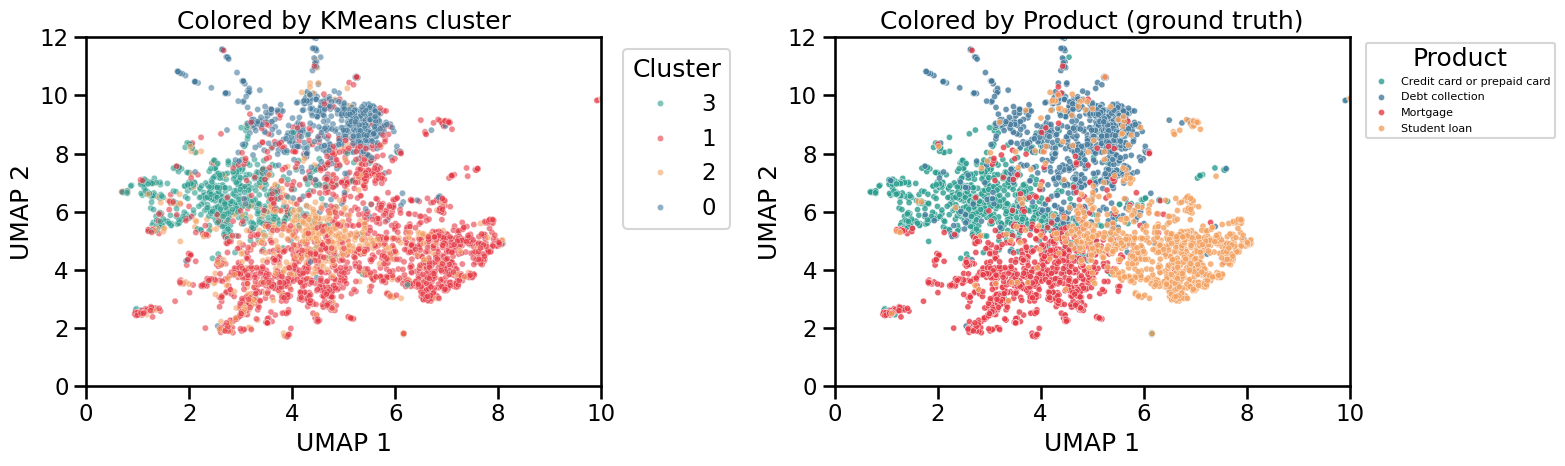

In [24]:
import umap

# 1) Compute 2D UMAP
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
).fit_transform(tf_dtm)

# 2) Plotting KMeans clusters vs actual Product categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: colored by KMeans cluster
cluster_palette = {
    '0': '#457B9D',
    '1': '#E63946',
    '2': '#F4A261',
    '3': '#2A9D8F',
}
sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=cfpb['kmeans_cluster'].astype(str),
    palette=cluster_palette,
    s=20,
    alpha=0.6,
    ax=axes[0],
)
axes[0].set_title('Colored by KMeans cluster')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# Right: colored by actual Product category
product_palette = {
    'Debt collection':  '#457B9D',
    'Mortgage':'#E63946',
    'Student loan': '#F4A261',
    'Credit card or prepaid card': '#2A9D8F',
}
sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=cfpb['Product'],
    palette=product_palette,
    s=20,
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Colored by Product (ground truth)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8)

# Same axis limits for both plots
for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()


### Choosing `k`: how many clusters?

KMeans requires you to specify `k` ahead of time, but in practice you usually don't know the "right" number. Two standard diagnostics help:

1. *Elbow method* — fit KMeans for a range of `k` values and plot the within-cluster sum of squares (called *inertia* in sklearn). As `k` grows, inertia always drops, but at some point the rate of decrease slows down — that "elbow" is a reasonable choice for `k`.

2. *Silhouette score* — for each point, measures how close it is to other points in *its own* cluster vs. the *nearest other* cluster. Ranges from -1 (badly assigned) to +1 (well separated). The `k` that maximizes the mean silhouette score is often a good pick.

These two diagnostics often disagree slightly, and that's fine — they're heuristics, not ground truth. In practice you'd:
- Pick a range of candidate `k` values (here, 2–10)
- Compute both metrics
- Look at the plots and choose a value supported by both, or one informed by domain knowledge


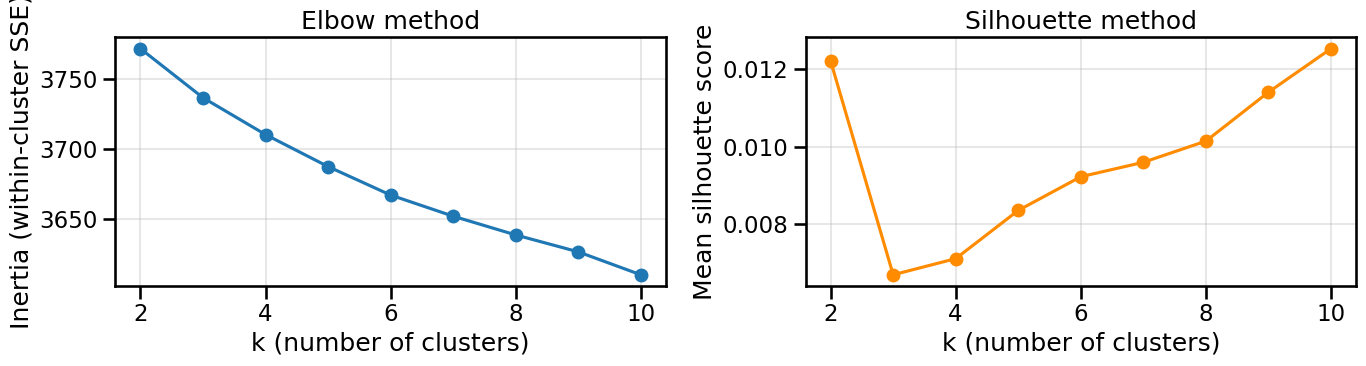

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of k values to evaluate
k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(tf_dtm)
    inertias.append(km.inertia_)
    
    score = silhouette_score(tf_dtm, km.labels_, random_state=42) #sample_size=1000, 
    silhouettes.append(score)
    # print(f"k={k:<2d}  inertia={km.inertia_:.1f}  silhouette={score:.3f}")


# Plotting the Elbow and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_range, silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Mean silhouette score')
axes[1].set_title('Silhouette method')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### HDBSCAN

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is the modern workhorse for density-based clustering. Unlike KMeans, this:

- Finds `k` automatically — clusters emerge from regions of high point density
- Handles arbitrary cluster shapes — not just spheres
- Identifies noise points — sparse points get label `-1` instead of being forced into a cluster
- Builds a hierarchy — like agglomerative clustering, but more robust to noise

It's the clustering step used inside BERTopic.

**Key parameters**
- `min_cluster_size` — smallest group of points that can be called a cluster 
- `min_samples` — minimum neighbors needed to consider a point part of a dense region

In [26]:
import hdbscan

# 1) HDBSCAN works much better on a lower-dimensional embedding than raw TF-IDF
umap_features = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
).fit_transform(tf_dtm)

# 2) Run HDBSCAN (prediction_data=True lets us recover a soft doc-cluster matrix)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200, # minimum size of clusters
    min_samples=5, # become a core point if its eps-neighborhood contains at least 5 points,
    metric='euclidean',
    prediction_data=True,
).fit(umap_features)


/Users/young/.pixi/envs/base/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [27]:
# Document-cluster matrix: each row is a document, each column is a cluster.
# all_points_membership_vectors returns soft membership probabilities,
# parallel to LDA's doc-topic matrix. Noise points get label -1.
doc_cluster_hdb = hdbscan.all_points_membership_vectors(clusterer)
print(f"Shape: {doc_cluster_hdb.shape}  (n_documents × n_clusters)")
print("First 5 rows:")
print(doc_cluster_hdb[:5])

# Attach the dominant cluster and its strength to each document.
# Use the labels_ from HDBSCAN directly (so noise stays as -1);
# strength comes from clusterer.probabilities_ (0 for noise).
cfpb['hdbscans_cluster'] = clusterer.labels_
cfpb['hdbscans_cluster_strength'] = clusterer.probabilities_

cfpb[['Product', 'hdbscans_cluster', 'hdbscans_cluster_strength', 'text_clean']].sample(10, random_state=42)


Shape: (4000, 4)  (n_documents × n_clusters)
First 5 rows:
[[3.77644738e-002 1.35503099e-001 6.51610586e-002 2.74260989e-002]
 [6.47906665e-309 1.00000000e+000 2.32183812e-308 6.29499576e-309]
 [5.09350353e-002 2.49891464e-001 1.41878779e-001 5.61167361e-002]
 [6.51678633e-002 2.08770903e-001 1.78283055e-001 4.97367320e-002]
 [9.44803270e-002 2.23106596e-001 4.39037441e-001 1.63330626e-001]]


,Product,hdbscans_cluster,hdbscans_cluster_strength,text_clean
555,Credit card or prepaid card,-1,0.000000,DIGIT brought attention navy federal credit un...
3491,Student loan,3,1.000000,ve attempts contact mohela lender overseeing p...
527,Credit card or prepaid card,-1,0.000000,multiple DIGIT DIGIT days late marks clear vio...
3925,Student loan,-1,0.000000,multiple DIGIT DIGIT days late marks clear vio...
2989,Mortgage,-1,0.000000,letter dated point digital finance inc. reject...
70,Credit card or prepaid card,1,0.961943,signed day trading course agreement DIGIT paym...
1756,Debt collection,0,0.820177,friday wife ii called credit card division ord...
211,Credit card or prepaid card,0,0.688058,account number appears charge account specific...
196,Credit card or prepaid card,-1,0.000000,aafes credit card military exchanges refuses p...
803,Credit card or prepaid card,1,1.000000,purchased furniture . use genesis financial se...


In [28]:
# Distribution of assigned clusters
n_clusters = (cfpb['hdbscans_cluster'] >= 0).sum() and cfpb['hdbscans_cluster'].max() + 1
n_noise = (cfpb['hdbscans_cluster'] == -1).sum()
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points:   {n_noise} ({n_noise / len(cfpb):.1%})")
print()
print("Cluster sizes:")
print(cfpb['hdbscans_cluster'].value_counts().sort_index())

Number of clusters found: 4
Number of noise points:   1760 (44.0%)

Cluster sizes:
hdbscans_cluster
-1    1760
 0     711
 1     260
 2     714
 3     555
Name: count, dtype: int64


In [29]:
# Crosstab — HDBSCAN dominant cluster × Product:
pd.crosstab(cfpb['hdbscans_cluster'], cfpb['Product'])

Product,Credit card or prepaid card,Debt collection,Mortgage,Student loan
hdbscans_cluster,,,,
-1,643,339,474,304
0,45,593,26,47
1,220,15,20,5
2,86,47,471,110
3,6,6,9,534


In [30]:
# For each cluster, show the top 3 documents with the highest cluster strength (skip noise)
for cluster_id in sorted(cfpb['hdbscans_cluster'].unique()):
    if cluster_id == -1:
        continue
    top_docs = cfpb[cfpb['hdbscans_cluster'] == cluster_id].nlargest(
        3, 'hdbscans_cluster_strength'
    )['Consumer complaint narrative']
    print(f"\n=== Cluster {cluster_id} ===")
    for doc in top_docs:
        print(f"  - {doc[:200]}...")



=== Cluster 0 ===
  - Edit this section What happened? 
Requested more info on {$39.00} charge I did not recognize. INK escalated to fraud incident. Weeks go by I hear nothing. I ask of matter many times. They obfuscate, h...
  - * I have no been able to use my AMEX card for 6months plus due to AMEX not lawfully updating my account properly so I am able to use my line of credit. 
* Essential consumer goods or services are vita...
  - I sent Amex and their registered agent a billing error notice. They have 30 days to reply. As a consumer, they failed to apply a credit that I am due, and also they withheld this disclosure from me. P...

=== Cluster 1 ===
  - Hello - my unused Visa had a value of XXXX dollars. It is expired. I contacted company phone # XXXX and requested a refund. The representative XXXX XXXX It's expired, and the card lost the {$50.00} va...
  - I had my company Credit card Account # XXXX XX/XX/26 XXXX From BOA. 
My grand daughter was always managing our payments and ma

In [31]:
# Identify top terms for each HDBSCAN cluster based on mean TF-IDF
terms = vectorizer.get_feature_names_out()
n_top_words = 10

for cluster_id in sorted(cfpb['hdbscans_cluster'].unique()):
    if cluster_id == -1:
        continue  # skip noise

    mask = (cfpb['hdbscans_cluster'] == cluster_id).values
    cluster_mean = np.asarray(tf_dtm[mask].mean(axis=0)).flatten()

    top_indices = cluster_mean.argsort()[::-1][:n_top_words]
    top_words = [terms[idx] for idx in top_indices]
    print(f"Cluster {cluster_id} (n={mask.sum()}): {', '.join(top_words)}")


Cluster 0 (n=711): debt, credit, digit, collection, report, account, reporting, company, information, validation
Cluster 1 (n=260): card, digit, credit, bank, america, charges, account, fraud, number, called
Cluster 2 (n=714): digit, loan, mortgage, payment, insurance, escrow, home, payments, account, paid
Cluster 3 (n=555): loans, digit, navient, loan, mohela, student, payments, forbearance, payment, plan


/Users/young/.pixi/envs/base/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


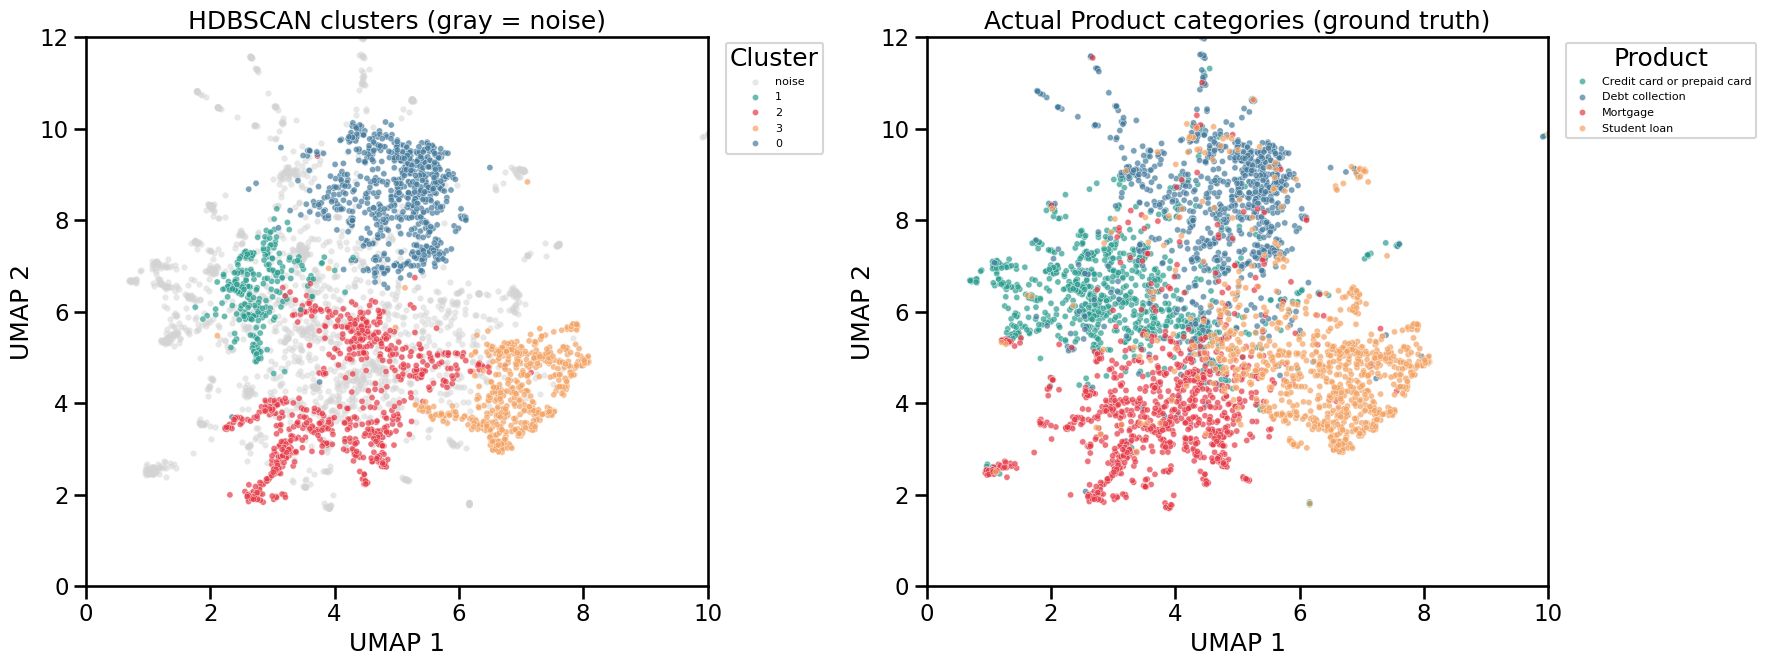

In [32]:
# 1) Compute 2D UMAP
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
).fit_transform(tf_dtm)

# 2) Plotting HDBSCAN clusters vs actual Product categories
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: HDBSCAN clusters ─────────────────────────────────────
noise_mask = cfpb['hdbscans_cluster'] == -1

# noise in gray
axes[0].scatter(
    umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
    c='lightgray', s=10, alpha=0.4, label='noise',
)

cluster_palette = {
    '0': '#457B9D',
    '1': '#2A9D8F',
    '2': '#E63946',
    '3': '#F4A261',
}

# actual clusters
sns.scatterplot(
    x=umap_2d[~noise_mask, 0],
    y=umap_2d[~noise_mask, 1],
    hue=cfpb.loc[~noise_mask, 'hdbscans_cluster'].astype(str),
    palette=cluster_palette,
    s=20, alpha=0.7,
    ax=axes[0],
    legend='brief',
)
axes[0].set_title('HDBSCAN clusters (gray = noise)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# ── Right: actual Product categories ───────────────────────────
product_palette = {
    'Debt collection':                '#457B9D',
    'Mortgage':                       '#E63946',
    'Student loan':                   '#F4A261',
    'Credit card or prepaid card':    '#2A9D8F',
}

sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=cfpb['Product'],
    palette=product_palette,
    s=20, alpha=0.7,
    ax=axes[1],
)
axes[1].set_title('Actual Product categories (ground truth)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Set the same axis limits for both plots
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 12)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 12)

plt.tight_layout()
plt.show()


## Topic Modeling

So far, we've used clustering — KMeans, hierarchical, HDBSCAN — to put each document into *one* group. But documents often touch multiple themes at once. A single mortgage complaint might mix escrow problems, customer-service frustration, and concerns about credit reporting. Forcing it into one cluster loses that nuance.

*Topic modeling* takes a different view. Instead of partitioning documents, it assumes:

- Each document is a *mixture* of latent topics (e.g., 60% "escrow issues", 30% "customer service", 10% "credit reporting")
- Each topic is a *distribution* over words (e.g., the "escrow" topic puts high weight on `escrow`, `tax`, `insurance`, `payment`, `shortage`)

The same document can express several topics in different proportions. The same word can appear in multiple topics with different weights. This is much closer to how text actually works.

We'll start with the classic probabilistic topic model — Latent Dirichlet Allocation (LDA).


### Latent Dirichlet Allocation (LDA)

LDA is a *generative* probabilistic model that assumes:

<img src='./images/lda.png' alt="lda" width="800">

(image from Maier et al. 2018)

1. Each *topic* is a distribution over words (e.g., topic A = {escrow: 0.08, payment: 0.05, tax: 0.04, ...}).
2. Each *document* is a mixture over topics (e.g., doc 1 = {topic A: 0.6, topic B: 0.3, topic C: 0.1}).
3. To "write" a document, you repeatedly:
   - Pick a topic from the document's topic mixture
   - Pick a word from that topic's word distribution

And we reverse-engineer plausible topics and topic mixtures from real text using math.

**What LDA gives you**

- *Topic-word matrix* — for each of K topics, the probability of every word in the vocabulary
- *Document-topic matrix* — for each document, its proportion of each of the K topics

**Key choices**

- *Number of topics (n_components)* — like `k` in KMeans, you have to pick it. Standard practice: try several values and pick by interpretability or coherence score.
- *Input representation* — LDA assumes integer word counts (bag-of-words).
- *Iterations* — LDA fits by iterative updates; more iterations = better convergence but slower.

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# LDA expects raw word counts (not TF-IDF)
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=2,
    max_df=0.95,
    max_features=None,
)

count_matrix = count_vectorizer.fit_transform(cfpb['text_clean'])
print(f"Document-term matrix shape: {count_matrix.shape}")

Document-term matrix shape: (4000, 7631)


In [34]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=4,   # adjust the # of components
                                max_iter=20,      # adjust the # of iterations to fit model
                                random_state=42)   # set seed for reproducibility

lda = lda.fit(count_matrix) 
# lda = lda.fit(tf_dtm)  # fit the LDA model to the TF-IDF matrix
print("LDA training done.")

LDA training done.


In [35]:
# Document-topic matrix: each row is a document, each column is a topic
doc_topic = lda.transform(count_matrix)
print(f"Shape: {doc_topic.shape}  (n_documents × n_topics)")
print("First 5 rows:")
print(doc_topic[:5])

# Attach the dominant topic to each document
cfpb['lda_topic'] = np.argmax(doc_topic, axis=1)
cfpb['lda_topic_strength'] = doc_topic.max(axis=1)

cfpb[['Product', 'lda_topic',  'lda_topic_strength', 'text_clean']].sample(10, random_state=42)


Shape: (4000, 4)  (n_documents × n_topics)
First 5 rows:
[[0.93456295 0.00450457 0.05639666 0.00453583]
 [0.84299378 0.00831324 0.00826679 0.14042618]
 [0.84860394 0.00442211 0.14249011 0.00448385]
 [0.66048072 0.31393482 0.01261216 0.01297229]
 [0.77434895 0.08446275 0.01063562 0.13055268]]


,Product,lda_topic,lda_topic_strength,text_clean
555,Credit card or prepaid card,2,0.540474,DIGIT brought attention navy federal credit un...
3491,Student loan,1,0.875613,ve attempts contact mohela lender overseeing p...
527,Credit card or prepaid card,2,0.962899,multiple DIGIT DIGIT days late marks clear vio...
3925,Student loan,2,0.962899,multiple DIGIT DIGIT days late marks clear vio...
2989,Mortgage,3,0.505357,letter dated point digital finance inc. reject...
70,Credit card or prepaid card,0,0.833444,signed day trading course agreement DIGIT paym...
1756,Debt collection,0,0.654208,friday wife ii called credit card division ord...
211,Credit card or prepaid card,2,0.628783,account number appears charge account specific...
196,Credit card or prepaid card,0,0.604535,aafes credit card military exchanges refuses p...
803,Credit card or prepaid card,0,0.961084,purchased furniture . use genesis financial se...


In [36]:
# Distribution of assigned topics
cfpb['lda_topic'].value_counts().sort_index()

lda_topic
0    1600
1     805
2     872
3     723
Name: count, dtype: int64

In [37]:
# Crosstab — LDA dominant topic × Product:
pd.crosstab(cfpb['lda_topic'], cfpb['Product'])

Product,Credit card or prepaid card,Debt collection,Mortgage,Student loan
lda_topic,,,,
0,902,290,228,180
1,6,15,64,720
2,84,648,51,89
3,8,47,657,11


In [38]:
# For each topic, show the top 3 documents with the highest topic strength
for topic_id in sorted(cfpb['lda_topic'].unique()):
    top_docs = cfpb[cfpb['lda_topic'] == topic_id].nlargest(
        3, 'lda_topic_strength'
    )['Consumer complaint narrative']
    print(f"\n=== Topic {topic_id} ===")
    for doc in top_docs:
        print(f"  - {doc[:200]}...")


=== Topic 0 ===
  - In about autumn XXXX, XXXX turned my account XXXX, despite my many emails and calls about that and attempts to turn it in XXXX again, and despite my attached emails and calls to XXXX about defective p...
  - 1. The Synchrony Bank Fraud Department knowingly took our money and created a {$1200.00} credit balance in our new XXXX XXXX XXXX MasterCard, although we had asked them to XXXX-balance the account, wh...
  - This complaint is in regards to Comenity Banks deceptive practices in regards to their XXXX Credit Card and promotional APRs. To preface, I speak from a perspective of someone who analyzes web and UX ...

=== Topic 1 ===
  - Hello, 
When I started my college education to become a XXXX XXXX I had spoke to finical aide office as I had concerns on taking out loans. I was informed that I had no issues to worry about because m...
  - I went to XXXX school betweenXX/XX/XXXXand XX/XX/XXXX During this time I took out loans through XXXX  XXXX XXXX for both years tot

In [39]:
# topic-word matrix from lda.components_ For each topic, show the top words by probability
terms = count_vectorizer.get_feature_names_out()
n_top_words = 10
topic_counts = cfpb['lda_topic'].value_counts()

doc_topic_word = lda.components_
print(f"Topic-word matrix shape: {doc_topic_word.shape}  (n_topics × n_terms)")

# print("Topic 0 — first 10 terms:")
# sample = pd.DataFrame({
#     'term': terms[:10],
#     'weight': doc_topic_word[0][:10],
# })
# display(sample)

# For each topic, show the top words 
for topic_id, topic_dist in enumerate(doc_topic_word):
    top_indices = topic_dist.argsort()[::-1][:n_top_words]
    top_words = [terms[i] for i in top_indices]
    print(f"Topic {topic_id} (n={topic_counts[topic_id]}): {', '.join(top_words)}")

Topic-word matrix shape: (4, 7631)  (n_topics × n_terms)
Topic 0 (n=1600): digit, account, credit, card, payment, bank, called, told, received, said
Topic 1 (n=805): loan, digit, payments, loans, payment, student, navient, time, plan, mohela
Topic 2 (n=872): digit, credit, debt, report, account, information, reporting, collection, consumer, request
Topic 3 (n=723): digit, mortgage, loan, home, insurance, company, escrow, property, received, told


/Users/young/.pixi/envs/base/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


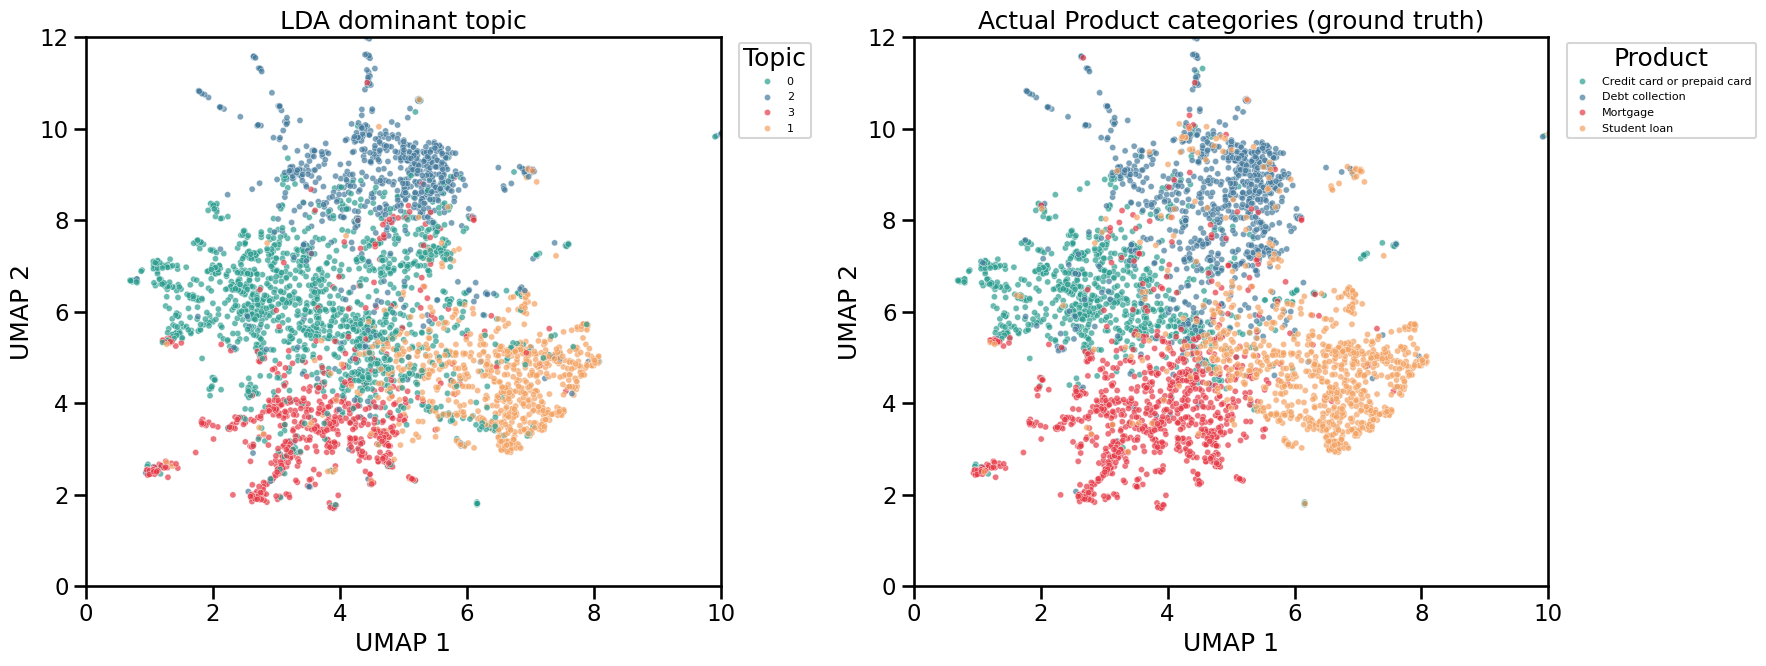

In [40]:
# 1) Compute 2D UMAP (reuse the same projection)
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
).fit_transform(tf_dtm)

# 2) Plotting LDA dominant topics vs actual Product categories
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: LDA dominant topics ──────────────────────────────────
topic_palette = {
    '0': '#2A9D8F',
    '1': '#F4A261',
    '2': '#457B9D',
    '3': '#E63946',
}

sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=cfpb['lda_topic'].astype(str),
    palette=topic_palette,
    s=20, alpha=0.7,
    ax=axes[0],
    legend='brief',
)
axes[0].set_title('LDA dominant topic')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# ── Right: actual Product categories ───────────────────────────
product_palette = {
    'Debt collection':                '#457B9D',
    'Mortgage':                       '#E63946',
    'Student loan':                   '#F4A261',
    'Credit card or prepaid card':    '#2A9D8F',
}

sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=cfpb['Product'],
    palette=product_palette,
    s=20, alpha=0.7,
    ax=axes[1],
)
axes[1].set_title('Actual Product categories (ground truth)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Same axis limits for both plots
for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()


### BERTopic

LDA is the classic but it has two well-known limitations:
1. It treats text as a bag of words — `card`, `cards`, `credit-card`, `Visa` are all unrelated tokens.
2. Short documents and noisy spelling hurt it.

BERTopic side-steps both issues by chaining together modern components:

<img src='./images/bertopic.svg' alt="bertopic" width="400">

(image from [here](https://maartengr.github.io/BERTopic/algorithm/algorithm.html))


1. *Embedding* — each document is turned into a dense vector with a pretrained sentence-transformer
2. *Dimensionality reduction* — UMAP projects embeddings (typically 384-D) down to ~5 dimensions for clustering.
3. *Clustering* — HDBSCAN groups the reduced vectors into topics. 
4. *Topic representation (c-TF-IDF)* — for each topic, BERTopic computes a topic-based TF-IDF.


To review the full list of pretrained models:
- https://www.sbert.net/docs/sentence_transformer/pretrained_models.html
- `sentence-transformers/all-mpnet-base-v2` has the best quality, `sentence-transformers/all-MiniLM-L6-v2` is ~5x faster with still-good quality.
- for Korean embedding: 
    - `paraphrase-multilingual-MiniLM-L12-v2` default multi-lingual model
    - `jhgan/ko-sroberta-multitask` from this [repo](https://github.com/jhgan00/ko-sentence-transformers)
    - `snunlp/KR-SBERT-V40K-klueNLI-augSTS` from this [repo](https://github.com/snunlp/KR-SBERT?utm_source=chatgpt.com)

In [41]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# 1) Pre-compute sentence embeddings once 
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
docs = cfpb['text_clean'].tolist()
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embedding matrix shape: {embeddings.shape}  (n_documents × embedding_dim)")

# 2) Fit BERTopic
#    calculate_probabilities=True gives us a soft doc-topic matrix (slower to fit).
topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics=5, #  final number of topics (clusters) including the DBSCAN noise group (-1) or set to 'auto' to let BERTopic find the optimal number
    calculate_probabilities=True, # results from hdbscan.all_points_membership_vectors(clusterer), if false, clusterer.probabilities_
)
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding matrix shape: (4000, 384)  (n_documents × embedding_dim)


In [42]:
# Document-topic matrix
# Rows = documents, columns = topics; values are soft membership probabilities.
doc_topic_bert = probs
print(f"Shape: {doc_topic_bert.shape}  (n_documents × n_topics)")
print("First 5 rows:")
print(doc_topic_bert[:5])

# Attach the dominant topic and its strength to each document.
# BERTopic uses -1 for outliers (HDBSCAN noise), same convention as the HDBSCAN section.
cfpb['bert_topic'] = topics
cfpb['bert_topic_strength'] = probs.max(axis=1)

cfpb[['Product', 'bert_topic', 'bert_topic_strength', 'text_clean']].sample(10, random_state=42)


Shape: (4000, 4)  (n_documents × n_topics)
First 5 rows:
[[9.34386604e-001 3.10605285e-002 2.61497252e-002 8.40314210e-003]
 [1.00000000e+000 6.21744989e-308 5.01942147e-308 1.81781348e-308]
 [9.08489490e-001 4.30720188e-002 3.55917216e-002 1.28467694e-002]
 [8.81108435e-001 5.63202196e-002 4.67630835e-002 1.58082618e-002]
 [2.95896339e-001 6.44194890e-003 4.70656154e-003 1.95760079e-003]]


,Product,bert_topic,bert_topic_strength,text_clean
555,Credit card or prepaid card,0,0.457127,DIGIT brought attention navy federal credit un...
3491,Student loan,0,0.528118,ve attempts contact mohela lender overseeing p...
527,Credit card or prepaid card,-1,0.000096,multiple DIGIT DIGIT days late marks clear vio...
3925,Student loan,-1,0.000096,multiple DIGIT DIGIT days late marks clear vio...
2989,Mortgage,-1,0.798816,letter dated point digital finance inc. reject...
70,Credit card or prepaid card,0,0.897678,signed day trading course agreement DIGIT paym...
1756,Debt collection,-1,0.750718,friday wife ii called credit card division ord...
211,Credit card or prepaid card,1,0.009243,account number appears charge account specific...
196,Credit card or prepaid card,0,0.883740,aafes credit card military exchanges refuses p...
803,Credit card or prepaid card,0,0.891616,purchased furniture . use genesis financial se...


In [43]:
# Distribution of assigned topics (-1 = outliers)
print(cfpb['bert_topic'].value_counts().sort_index())

bert_topic
-1     861
 0    3038
 1      63
 2      26
 3      12
Name: count, dtype: int64


In [44]:
# Crosstab — BERTopic dominant topic × Product:
pd.crosstab(cfpb['bert_topic'], cfpb['Product'])

Product,Credit card or prepaid card,Debt collection,Mortgage,Student loan
bert_topic,,,,
-1,48,30,435,348
0,950,872,564,652
1,1,62,0,0
2,0,26,0,0
3,1,10,1,0


In [45]:
# For each topic, show the top 3 documents with the highest topic strength (skip outliers)
for topic_id in sorted(cfpb['bert_topic'].unique()):
    if topic_id == -1:
        continue
    top_docs = cfpb[cfpb['bert_topic'] == topic_id].nlargest(
        3, 'bert_topic_strength'
    )['Consumer complaint narrative']
    print(f"\n=== Topic {topic_id} ===")
    for doc in top_docs:
        print(f"  - {doc[:200]}...")


=== Topic 0 ===
  - Hello - my unused Visa had a value of XXXX dollars. It is expired. I contacted company phone # XXXX and requested a refund. The representative XXXX XXXX It's expired, and the card lost the {$50.00} va...
  - In XX/XX/XXXX, I called XXXX XXXX to provide me the available balance transfer information and it was incorrect therefore when I tried to pay the Chase account credit card off the balance transfer che...
  - I received an email on XXXX XXXX, 2021, indicating that American Express was running a promotion associated with my Hilton XXXX card stating that if I spend a minimum of {$8000.00} on my card, I would...

=== Topic 1 ===
  - PORTFOLIO RC is falsely reporting on my credit. I have never had any accounts with them. Per my research PORTFOLIO RC is a debt collector. They are falsely reporting on my credit!! Account number is X...
  - There are collection accounts on my report that I believe contain inaccurate information. Under my rights pursuant to 15 USC 1681e

In [46]:
# Topic-word "matrix" — BERTopic uses c-TF-IDF (class-based TF-IDF) 
n_top_words = 10
topic_counts = cfpb['bert_topic'].value_counts()

for topic_id in sorted(topic_model.get_topics().keys()):
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)  # list of (word, c-tf-idf weight)
    top_words = [w for w, _ in words[:n_top_words]]
    print(f"Topic {topic_id} (n={topic_counts.get(topic_id, 0)}): {', '.join(top_words)}")


Topic 0 (n=3038): digit, credit, account, card, payment, debt, loan, received, information, payments
Topic 1 (n=63): report, accounts, credit, falsely, accurate, usc, inaccurate, entries, rights, reporting
Topic 2 (n=26): report, transactions, inclusion, blocked, accounts, authorize, entries, removed, crucial, records
Topic 3 (n=12): examine, invaluable, insights, expertise, ensuring, completeness, feedback, appreciated, moment, greatly


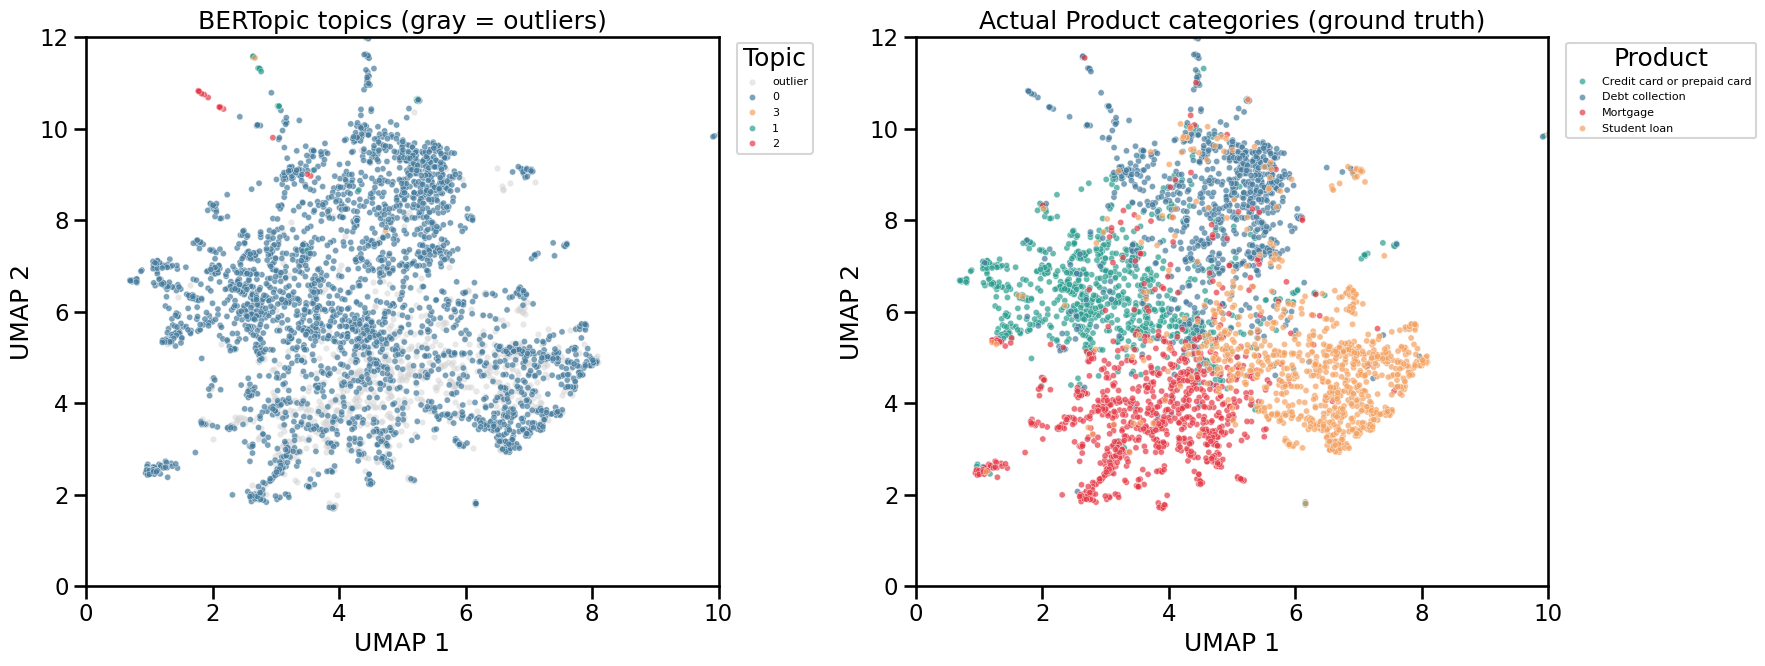

In [47]:
# 1) Compute 2D UMAP
umap_2d_bert = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
).fit_transform(tf_dtm)  # use the same UMAP projection as before for comparability

# 2) Plot BERTopic topics vs actual Product categories
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: BERTopic dominant topic (gray = outliers) ───────────
noise_mask = cfpb['bert_topic'] == -1
axes[0].scatter(
    umap_2d_bert[noise_mask, 0], umap_2d_bert[noise_mask, 1],
    c='lightgray', s=10, alpha=0.4, label='outlier',
)

topic_palette = {
    '0': '#457B9D',
    '1': '#2A9D8F',
    '2': '#E63946',
    '3': '#F4A261',
    '4': '#9B5DE5',
}

sns.scatterplot(
    x=umap_2d_bert[~noise_mask, 0],
    y=umap_2d_bert[~noise_mask, 1],
    hue=cfpb.loc[~noise_mask, 'bert_topic'].astype(str),
    palette=topic_palette,
    s=20, alpha=0.7,
    ax=axes[0],
    legend='brief',
)
axes[0].set_title('BERTopic topics (gray = outliers)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# ── Right: actual Product categories ──────────────────────────
product_palette = {
    'Debt collection':                '#457B9D',
    'Mortgage':                       '#E63946',
    'Student loan':                   '#F4A261',
    'Credit card or prepaid card':    '#2A9D8F',
}
sns.scatterplot(
    x=umap_2d_bert[:, 0],
    y=umap_2d_bert[:, 1],
    hue=cfpb['Product'],
    palette=product_palette,
    s=20, alpha=0.7,
    ax=axes[1],
)
axes[1].set_title('Actual Product categories (ground truth)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Same axis limits for both plots
for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()


#### BERTopic Useful APIs
- BERTopic provides a nice summary table of topic info `get_topic_info()`
- BERTopic has *Built-in visualizations* — `visualize_topics()`, `visualize_barchart()`, `visualize_heatmap()`, `visualize_hierarchy()` are all one-liners.

In [48]:
# BERTopic also provides a nice summary table of topic info, including size and top words.
pd.set_option('display.max_colwidth', 200)
topic_model.get_topic_info() # Rep Docs are based on TF-IDF similarities, not probabilities

,Topic,Count,Name,Representation,Representative_Docs
0,-1,861,-1_digit_loan_payment_mortgage,"[digit, loan, payment, mortgage, payments, told, account, loans, date, time]",[hello started college education spoke finical aide office concerns taking loans. informed issues worry loans forgiven qualified loan forgiveness. told definitely qualify . fedloan pa told consoli...
1,0,3038,0_digit_credit_account_card,"[digit, credit, account, card, payment, debt, loan, received, information, payments]",[wanted close aadvantage aviator red master barcays company . called . said want close card balanace pay off. told balance DIGIT.DIGIT . told different number close account need checking account r...
2,1,63,1_report_accounts_credit_falsely,"[report, accounts, credit, falsely, accurate, usc, inaccurate, entries, rights, reporting]",[collection accounts report believe contain inaccurate information. rights pursuant DIGIT usc DIGITe b DIGIT usc DIGITi entitled accurate credit report. request review entries verified accurate as...
3,2,26,2_report_transactions_inclusion_blocked,"[report, transactions, inclusion, blocked, accounts, authorize, entries, removed, crucial, records]",[want stress written permission specific transactions included consumer report. point authorize entries presence report unwarranted. consequently formally requesting accounts blocked removed repor...
4,3,12,3_examine_invaluable_insights_expertise,"[examine, invaluable, insights, expertise, ensuring, completeness, feedback, appreciated, moment, greatly]","[moment review examine attached documents? believe expertise invaluable ensuring accuracy completeness. feedback insights greatly appreciated. thank time consideration matter., moment review exami..."


In [49]:
# In a notebook, just calling them displays the figure inline.
topic_model.visualize_barchart(top_n_topics=4, n_words=8)

In [50]:
topic_model.visualize_heatmap() # TF-IDF similarity between topics (darker = more similar)

In [51]:
# 2D map of topics themselves (each bubble = a topic, size = topic size, distance = semantic similarity)
topic_model.visualize_topics()

# Takeaway
Clustering is partly technical, but it is also partly an *art*.
- Choosing k is difficult
- even when the number of clusters is selected automatically, the results can still be hard to interpret. 
- A cluster may reflect a meaningful document type, but it may also reflect repeated templates, writing style, document length, or artifacts of preprocessing.

In our example, BERTopic — though the most modern method — isn't automatically best at recovering the CFPB Product categories. Because it groups by semantic similarity, complaints with similar language can end up together even when they come from different Products.

Again, often the goal is not simply to find the “best” method. Instead, we want to understand what each method reveals about the same corpus, what it hides, and what kinds of assumptions it makes.
